In [1]:
#Project 1

# **1. Data Exploration & Preprocessing**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import joblib
import time

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn import metrics

In [3]:
#load the dataset and display first few rows
df = pd.read_excel("train_data with labels.xlsx")

df.head()

,text,label
0,Councils are debating if building housing area...,0
1,While reading the succesful people's lifes you...,0
2,"Finally, she felt that the robotics unit was i...",1
3,Since sigmoid can be viewed as a special 2clas...,1
4,In this essay we will talk about why in so man...,0


In [4]:
#check datset info
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nDataset info:")
df.info()

Dataset shape: (8176, 2)

Columns:
Index(['text', 'label'], dtype='object')

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8176 entries, 0 to 8175
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    8176 non-null   object
 1   label   8176 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 127.9+ KB


In [5]:
print(df["label"].value_counts())

label
0    4088
1    4088
Name: count, dtype: int64


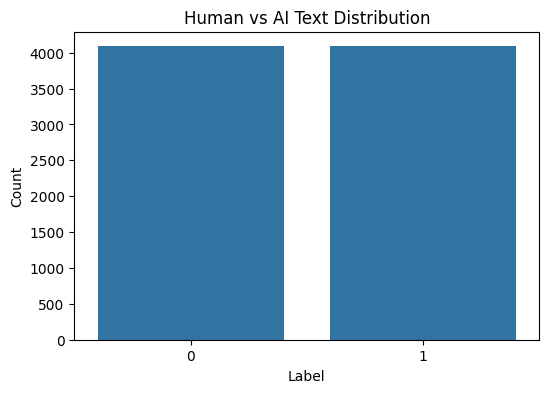

In [6]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="label",
    data=df
)

plt.title("Human vs AI Text Distribution")

plt.xlabel("Label")

plt.ylabel("Count")

plt.show()

In [7]:
# Check for missing values
print(df.isnull().sum())

text     0
label    0
dtype: int64


In [8]:
# clean the text
# remove capital, punctuaion, and extra spaces
def clean_text(text):

  text = str(text).lower()

  text = re.sub(r"[^a-zA-Z\s]", "", text)

  text = re.sub(r"\s+", " ", text)

  return text

In [9]:
df["clean_text"] = df["text"].apply(clean_text)

In [10]:
# Original vs clean comparison
print("Original:\n")
print(df["text"][0])

print("\n\nCleaned:\n")
print(df["clean_text"][0])

Original:

Councils are debating if building housing areas on expanded land is a better solution than providing taller dwellings. It might be an extremely complicated choice, considering the skyrocketing rise of number of people in the world and the change in prefering a walk-distance city. This essay will explore the optimal solutions for cities layout.
Although the ideal solution might depend on what the cities are aiming for, under a generic point of view, it would be optimal to have dwellings compacted in a dimished size of land. The first justification is that cramping everything in a reduced area and growing tall allowes all the residents to reach shops and workplaces in dwindling time through walking, public transport or eco-friendly vehicles. Moreover, taking in account the overall incresing of population's density, with the creation of a taller layout, a sustainable market demand will be shown.
Nowadays, the antiquated method of construct residences on a wider area of land is 

# **2. Feature Engineering**

In [11]:
# TF IDF is used here to turn the cleaned text into numerical features the models can learn from.
# It essentially gives higher scores to words that show up a lot in a document, but not across the whole dataset.

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [13]:
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

X_tfidf = tfidf.fit_transform(
    df["clean_text"]
)

In [14]:
print(X_tfidf.shape)

(8176, 5000)


In [15]:
# Features that describe the writing itself.
#They look at the length of the text and how many unique words are used.

In [16]:
df["word_count"] = df["clean_text"].apply(
    lambda x: len(x.split())
)

df["char_count"] = df["clean_text"].apply(
    lambda x: len(x)
)

df["vocab_richness"] = df["clean_text"].apply(
    lambda x: len(set(x.split())) / len(x.split()) if len(x.split()) > 0 else 0
)

df[["word_count", "char_count", "vocab_richness"]].head()

,word_count,char_count,vocab_richness
0,283,1742,0.618375
1,297,1687,0.491582
2,377,2258,0.511936
3,298,1833,0.496644
4,267,1576,0.513109


# **3. Model Training & Tuning**

In [17]:
X = df["clean_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(6540,)
(1636,)


In [18]:
from sklearn.svm import SVC

In [19]:
svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        stop_words="english",
        max_features=5000
    )),
    ("classifier", SVC())
])

In [20]:
svm_params = {
    "classifier__C": [0.1, 1, 10],
    "classifier__kernel": ["linear"]
}

In [21]:
svm_grid = GridSearchCV(
    svm_pipeline,
    svm_params,
    cv=3,
    scoring="accuracy",
    n_jobs=1
)

In [22]:
svm_grid.fit(
    X_train,
    y_train
)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('tfidf',
                                        TfidfVectorizer(max_features=5000,
                                                        stop_words='english')),
                                       ('classifier', SVC())]),
             n_jobs=1,
             param_grid={'classifier__C': [0.1, 1, 10],
                         'classifier__kernel': ['linear']},
             scoring='accuracy')

In [23]:
print("Best Parameters:")
print(svm_grid.best_params_)

print("\nBest Cross Validation Accuracy:")
print(svm_grid.best_score_)

Best Parameters:
{'classifier__C': 1, 'classifier__kernel': 'linear'}

Best Cross Validation Accuracy:
0.9529051987767584


In [24]:
# 3.3 Decision Tree

In [25]:
from sklearn.tree import DecisionTreeClassifier

In [26]:
dt_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        stop_words="english",
        max_features=5000
    )),
    ("classifier", DecisionTreeClassifier())
])

In [27]:
dt_params = {
    "classifier__max_depth": [5, 10, 20],
    "classifier__min_samples_split": [2, 5]
}

In [28]:
dt_grid = GridSearchCV(
    dt_pipeline,
    dt_params,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('tfidf',
                                        TfidfVectorizer(max_features=5000,
                                                        stop_words='english')),
                                       ('classifier',
                                        DecisionTreeClassifier())]),
             n_jobs=-1,
             param_grid={'classifier__max_depth': [5, 10, 20],
                         'classifier__min_samples_split': [2, 5]},
             scoring='accuracy')

In [29]:
print("Best Parameters:")
print(dt_grid.best_params_)

print("\nBest Cross Validation Accuracy:")
print(dt_grid.best_score_)

Best Parameters:
{'classifier__max_depth': 20, 'classifier__min_samples_split': 5}

Best Cross Validation Accuracy:
0.8652905198776759


In [30]:
# 3.4 AdaBoost

In [31]:
from sklearn.ensemble import AdaBoostClassifier

In [32]:
ada_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        stop_words="english",
        max_features=5000
    )),
    ("classifier", AdaBoostClassifier())
])

In [33]:
ada_params = {
    "classifier__n_estimators": [50, 100],
    "classifier__learning_rate": [0.5, 1.0]
}

In [34]:
ada_grid = GridSearchCV(
    ada_pipeline,
    ada_params,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

ada_grid.fit(X_train, y_train)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('tfidf',
                                        TfidfVectorizer(max_features=5000,
                                                        stop_words='english')),
                                       ('classifier', AdaBoostClassifier())]),
             n_jobs=-1,
             param_grid={'classifier__learning_rate': [0.5, 1.0],
                         'classifier__n_estimators': [50, 100]},
             scoring='accuracy')

In [35]:
print("Best Parameters:")
print(ada_grid.best_params_)

print("\nBest Cross Validation Accuracy:")
print(ada_grid.best_score_)

Best Parameters:
{'classifier__learning_rate': 1.0, 'classifier__n_estimators': 100}

Best Cross Validation Accuracy:
0.9163608562691131


In [36]:
# 3.5 FNN

In [37]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [38]:
X_train_tfidf = tfidf.transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Convert matric to array for keras
X_train_fnn = X_train_tfidf.toarray()
X_test_fnn = X_test_tfidf.toarray()

print(X_train_fnn.shape)
print(X_test_fnn.shape)

(6540, 5000)
(1636, 5000)


In [39]:
fnn_model = Sequential([
    Dense(128, activation="relu", input_shape=(X_train_fnn.shape[1],)),
    Dropout(0.3),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

fnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

fnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       640,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 656,769 (2.51 MB)

 Trainable params: 656,769 (2.51 MB)

 Non-trainable params: 0 (0.00 B)

In [40]:
history = fnn_model.fit(
    X_train_fnn,
    y_train,
    epochs=3,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/3
164/164 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8760 - loss: 0.3219 - val_accuracy: 0.9595 - val_loss: 0.1107
Epoch 2/3
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9849 - loss: 0.0467 - val_accuracy: 0.9648 - val_loss: 0.0977
Epoch 3/3
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9966 - loss: 0.0137 - val_accuracy: 0.9625 - val_loss: 0.1184


In [41]:
#3.6 LTSM

In [42]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [43]:
max_words = 10000
max_len = 200

# Turn the text to seq of integers
tokenizer = Tokenizer(num_words=max_words)

tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

#pad seq so theyre the same length
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_len
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_len
)

print(X_train_pad.shape)
print(X_test_pad.shape)

(6540, 200)
(1636, 200)


In [44]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

In [45]:
# turns each word index into learned vector
lstm_model = Sequential([
    Embedding(
        input_dim=max_words,
        output_dim=128,
        input_length=max_len
    ),

    LSTM(64),

    Dropout(0.3),

    Dense(1, activation="sigmoid")
])

lstm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [46]:
history_lstm = lstm_model.fit(
    X_train_pad,
    y_train,
    epochs=3,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/3
164/164 ━━━━━━━━━━━━━━━━━━━━ 26s 146ms/step - accuracy: 0.6523 - loss: 0.6241 - val_accuracy: 0.8631 - val_loss: 0.3798
Epoch 2/3
164/164 ━━━━━━━━━━━━━━━━━━━━ 24s 147ms/step - accuracy: 0.8438 - loss: 0.3674 - val_accuracy: 0.8609 - val_loss: 0.3621
Epoch 3/3
164/164 ━━━━━━━━━━━━━━━━━━━━ 24s 148ms/step - accuracy: 0.9331 - loss: 0.1852 - val_accuracy: 0.8609 - val_loss: 0.3636


In [47]:
#3.7 CNN

In [48]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D
from tensorflow.keras.layers import GlobalMaxPooling1D
from tensorflow.keras.layers import Dense, Dropout

cnn_model = Sequential([
    Embedding(max_words, 128, input_length=max_len),

    Conv1D(
        filters=128,
        kernel_size=5,
        activation="relu"
    ),

    GlobalMaxPooling1D(),

    Dropout(0.3),

    Dense(64, activation="relu"),

    Dense(1, activation="sigmoid")
])

cnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [49]:
history_cnn = cnn_model.fit(
    X_train_pad,
    y_train,
    epochs=3,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/3
164/164 ━━━━━━━━━━━━━━━━━━━━ 19s 105ms/step - accuracy: 0.7213 - loss: 0.5221 - val_accuracy: 0.8815 - val_loss: 0.2766
Epoch 2/3
164/164 ━━━━━━━━━━━━━━━━━━━━ 18s 107ms/step - accuracy: 0.9169 - loss: 0.2003 - val_accuracy: 0.9274 - val_loss: 0.1904
Epoch 3/3
164/164 ━━━━━━━━━━━━━━━━━━━━ 19s 101ms/step - accuracy: 0.9786 - loss: 0.0638 - val_accuracy: 0.9297 - val_loss: 0.1813


#4 Evaluation & Comparison

In [50]:
from sklearn.metrics import roc_curve, auc

In [51]:
#4.1 SVM Evlauatiion

In [52]:
y_pred = svm_grid.predict(X_test)

print(metrics.classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.96      0.97       811
           1       0.96      0.98      0.97       825

    accuracy                           0.97      1636
   macro avg       0.97      0.97      0.97      1636
weighted avg       0.97      0.97      0.97      1636



In [53]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[778  33]
 [ 19 806]]


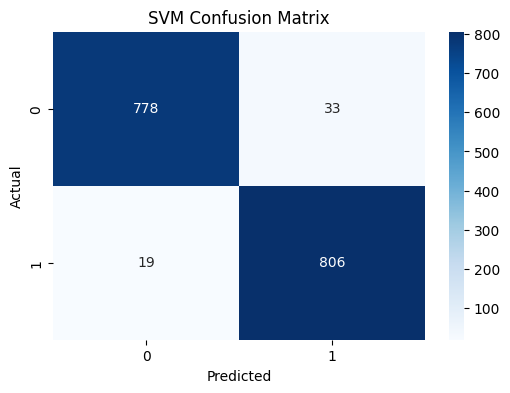

In [54]:
plt.figure(figsize=(6,4))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")
plt.show()

In [55]:
svm_accuracy = metrics.accuracy_score(y_test, y_pred)

print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.9682151589242054


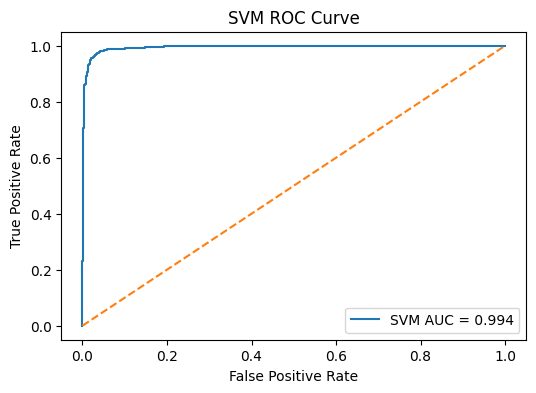

SVM AUC Score: 0.993899039719015


In [56]:
svm_scores = svm_grid.decision_function(X_test)

fpr_svm, tpr_svm, _ = roc_curve(
    y_test,
    svm_scores
)

roc_auc_svm = auc(
    fpr_svm,
    tpr_svm
)

plt.figure(figsize=(6,4))

plt.plot(
    fpr_svm,
    tpr_svm,
    label=f"SVM AUC = {roc_auc_svm:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("SVM ROC Curve")
plt.legend()

plt.show()

print("SVM AUC Score:", roc_auc_svm)

In [57]:
# 4.2 Decision Tree Evaluation

In [58]:
dt_pred = dt_grid.predict(X_test)

print(metrics.classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

           0       0.87      0.87      0.87       811
           1       0.87      0.87      0.87       825

    accuracy                           0.87      1636
   macro avg       0.87      0.87      0.87      1636
weighted avg       0.87      0.87      0.87      1636



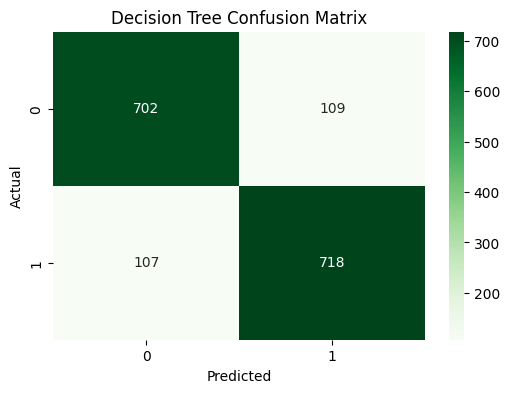

In [59]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, dt_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Greens")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")
plt.show()

In [60]:
dt_accuracy = metrics.accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.8679706601466992


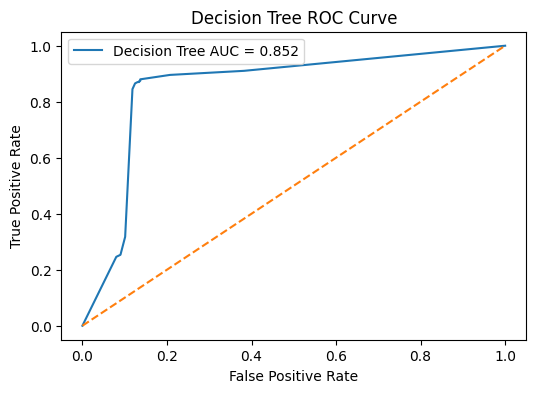

Decision Tree AUC Score: 0.8520913201061167


In [61]:
dt_probs = dt_grid.predict_proba(X_test)[:,1]

fpr_dt, tpr_dt, _ = roc_curve(
    y_test,
    dt_probs
)

roc_auc_dt = auc(
    fpr_dt,
    tpr_dt
)

plt.figure(figsize=(6,4))

plt.plot(
    fpr_dt,
    tpr_dt,
    label=f"Decision Tree AUC = {roc_auc_dt:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Decision Tree ROC Curve")
plt.legend()

plt.show()

print("Decision Tree AUC Score:", roc_auc_dt)

In [62]:
# 4.3 AdaBoost

In [63]:
ada_pred = ada_grid.predict(X_test)

print(metrics.classification_report(y_test, ada_pred))

              precision    recall  f1-score   support

           0       0.93      0.89      0.91       811
           1       0.89      0.94      0.92       825

    accuracy                           0.91      1636
   macro avg       0.91      0.91      0.91      1636
weighted avg       0.91      0.91      0.91      1636



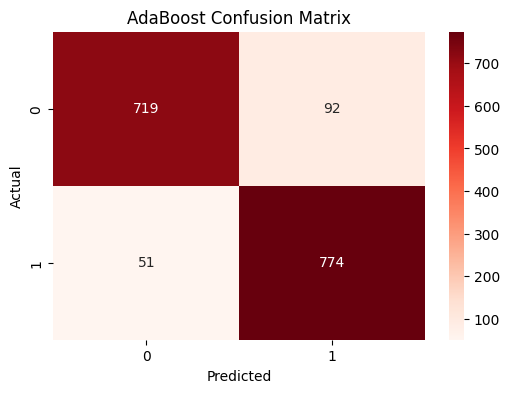

In [64]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, ada_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds")

plt.title("AdaBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [65]:
ada_accuracy = metrics.accuracy_score(y_test, ada_pred)

print("AdaBoost Accuracy:", ada_accuracy)

AdaBoost Accuracy: 0.9125916870415648


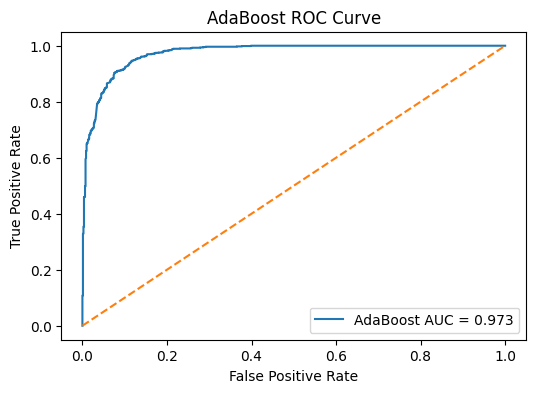

AdaBoost AUC Score: 0.9733923700631469


In [66]:
ada_probs = ada_grid.predict_proba(X_test)[:,1]

fpr_ada, tpr_ada, _ = roc_curve(
    y_test,
    ada_probs
)

roc_auc_ada = auc(
    fpr_ada,
    tpr_ada
)

plt.figure(figsize=(6,4))

plt.plot(
    fpr_ada,
    tpr_ada,
    label=f"AdaBoost AUC = {roc_auc_ada:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("AdaBoost ROC Curve")
plt.legend()

plt.show()

print("AdaBoost AUC Score:", roc_auc_ada)

In [67]:
# 4.4 FNN

In [68]:
# convert probablities into class labels
fnn_pred = (fnn_model.predict(X_test_fnn) > 0.5).astype(int)

print(metrics.classification_report(y_test, fnn_pred))

52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
              precision    recall  f1-score   support

           0       0.93      0.98      0.95       811
           1       0.98      0.92      0.95       825

    accuracy                           0.95      1636
   macro avg       0.95      0.95      0.95      1636
weighted avg       0.95      0.95      0.95      1636



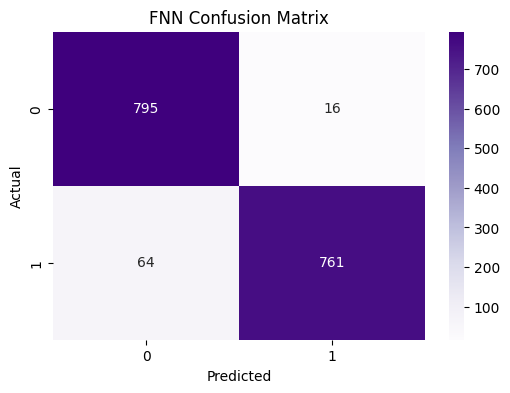

In [69]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, fnn_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples"
)

plt.title("FNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [70]:
fnn_accuracy = metrics.accuracy_score(y_test, fnn_pred)

print("FNN Accuracy:", fnn_accuracy)

FNN Accuracy: 0.9511002444987775


In [71]:
# 4.5 LTSM

In [72]:
lstm_pred = (lstm_model.predict(X_test_pad) > 0.5).astype(int)

print(metrics.classification_report(y_test, lstm_pred))

52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step
              precision    recall  f1-score   support

           0       0.86      0.79      0.83       811
           1       0.81      0.88      0.84       825

    accuracy                           0.84      1636
   macro avg       0.84      0.84      0.84      1636
weighted avg       0.84      0.84      0.84      1636



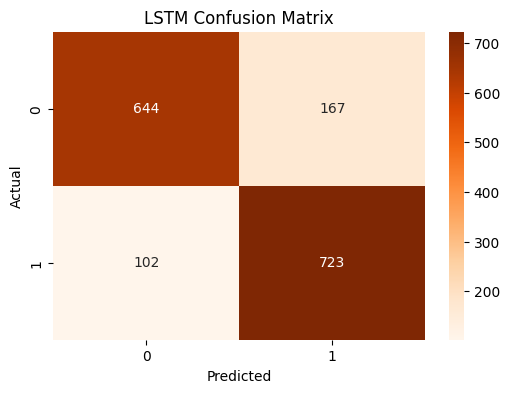

In [73]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, lstm_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title("LSTM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [74]:
lstm_accuracy = metrics.accuracy_score(
    y_test,
    lstm_pred
)

print("LSTM Accuracy:", lstm_accuracy)

LSTM Accuracy: 0.8355745721271394


In [75]:
# 4.6 CNN

In [76]:
cnn_pred = (cnn_model.predict(X_test_pad) > 0.5).astype(int)

print(
    metrics.classification_report(
        y_test,
        cnn_pred
    )
)

52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step
              precision    recall  f1-score   support

           0       0.93      0.95      0.94       811
           1       0.95      0.93      0.94       825

    accuracy                           0.94      1636
   macro avg       0.94      0.94      0.94      1636
weighted avg       0.94      0.94      0.94      1636



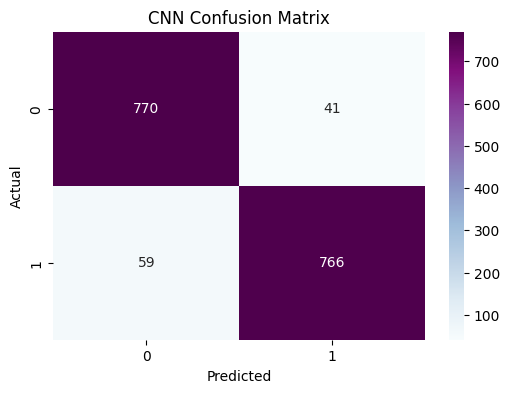

In [77]:
cm = confusion_matrix(y_test, cnn_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="BuPu")

plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [78]:
cnn_accuracy = metrics.accuracy_score(
    y_test,
    cnn_pred
)

print("CNN Accuracy:", cnn_accuracy)

CNN Accuracy: 0.9388753056234719


In [79]:
# Model Comaprison

In [80]:
results_all = pd.DataFrame({
    "Model": [
        "SVM",
        "Decision Tree",
        "AdaBoost",
        "FNN",
        "LSTM",
        "CNN"
    ],
    "Accuracy": [
        svm_accuracy,
        dt_accuracy,
        ada_accuracy,
        fnn_accuracy,
        lstm_accuracy,
        cnn_accuracy
    ]
})

print(
    results_all.sort_values(
        by="Accuracy",
        ascending=False
    )
)

           Model  Accuracy
0            SVM  0.968215
3            FNN  0.951100
5            CNN  0.938875
2       AdaBoost  0.912592
1  Decision Tree  0.867971
4           LSTM  0.835575


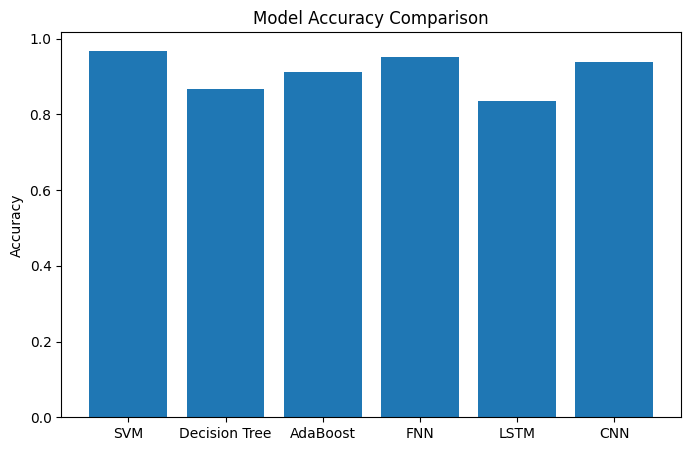

In [81]:
plt.figure(figsize=(8,5))

plt.bar(
    results_all["Model"],
    results_all["Accuracy"]
)

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.show()

In [82]:
results_all.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy
0,SVM,0.968215
3,FNN,0.951100
5,CNN,0.938875
2,AdaBoost,0.912592
1,Decision Tree,0.867971
4,LSTM,0.835575


In [83]:
# Save Models for Streamlit

In [84]:
joblib.dump(
    svm_grid.best_estimator_,
    "svm_model.pkl"
)

joblib.dump(
    dt_grid.best_estimator_,
    "decision_tree_model.pkl"
)

joblib.dump(
    ada_grid.best_estimator_,
    "adaboost_model.pkl"
)

joblib.dump(
    tfidf,
    "tfidf_vectorizer.pkl"
    )

joblib.dump(
    tokenizer,
    "tokenizer.pkl"
  )

print("Vectorizer and tokenizer saved!")

print("Models saved successfully!")

Vectorizer and tokenizer saved!
Models saved successfully!


In [85]:
fnn_model.save("fnn_model.h5")

lstm_model.save("lstm_model.h5")

cnn_model.save("cnn_model.h5")

print("Deep Learning models saved!")

Deep Learning models saved!


**Results Analysis**

After running all 6 models, the SVM had the highest accuracy at 96.82% and was the most reliable. That was surprising to me, as I thought one of the deep learning models would have the highest accuracy. The FNN came really close with 95.11% accuracy, making me think that TF IDF carries a lot of weight in this dataset. The CNN also performed well with 93.89% accuracy, but the LSTM struggled far more than I expected. Likely because I didn't spend a lot of time tuning sequence lengths or embedding sizes The Decision Tree also did fairly well, but the AdaBoost struggled a bit.

The TF IDF was pretty strong across the board. Even the simpler models performed well with it, which shows that the differnces between the two writing styles show up pretty clearly in word usage patterns. The extra text statistics like word count and vocabulary richness didn't change the results much, but they did help to understanfd the dataset better. When looking at misclassifications, a lot of them were generic sentences where it's pretty much a toss up if it's human or not. Some AI text looks very natural, and some human writing can look very AI ish.

If I were to use this in a real classroom, I wouldn't rely on it as the final decision maker. It's better used as a tool that alerts you of AI signals, rather than the end all be all of whether it was used or not.